In [61]:
import pathlib
from tqdm import tqdm

import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [62]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

file_name = "data"
data_path = pathlib.Path("data")

train_df = pd.read_csv(data_path / f"{file_name}_train.csv")
valid_df = pd.read_csv(data_path / f"{file_name}_valid.csv")
test_df = pd.read_csv(data_path / f"{file_name}_test.csv")

input_col_names = ['time', 're', 'x', 'y']
target_col_names = ['U_x', 'U_y', 'p']

In [63]:
train_df.describe()

,time,re,x,y,U_x,U_y,p
count,24576.000000,24576.000000,24576.000000,24576.000000,24576.000000,24576.000000,24576.000000
mean,0.200000,662.500000,0.044181,0.050000,0.000057,0.012094,-0.020476
std,0.163303,112.502289,0.028747,0.028865,0.167980,0.107028,0.093597
min,0.000000,550.000000,0.000541,0.000781,-0.229171,-0.496671,-3.047410
25%,0.000000,550.000000,0.019156,0.025391,-0.065646,0.000000,-0.043411
50%,0.200000,662.500000,0.041292,0.050000,-0.003512,0.000000,-0.000137
75%,0.400000,775.000000,0.067615,0.074609,0.000000,0.040804,0.000000
max,0.400000,775.000000,0.098918,0.099219,0.953575,0.321847,2.758810


In [64]:
valid_df.describe()

,time,re,x,y,U_x,U_y,p
count,12288.000000,12288.0,12288.000000,12288.000000,12288.000000,12288.000000,12288.000000
mean,0.200000,325.0,0.044181,0.050000,0.000056,0.012970,-0.021149
std,0.163306,0.0,0.028747,0.028865,0.172889,0.111938,0.173038
min,0.000000,325.0,0.000541,0.000781,-0.212282,-0.431154,-5.260850
25%,0.000000,325.0,0.019156,0.025391,-0.072079,-0.000257,-0.032438
50%,0.200000,325.0,0.041292,0.050000,-0.003608,0.000000,0.000000
75%,0.400000,325.0,0.067615,0.074609,0.000000,0.038148,0.000000
max,0.400000,325.0,0.098918,0.099219,0.954056,0.339638,4.362110


In [65]:
test_df.describe()

,time,re,x,y,U_x,U_y,p
count,49152.000000,49152.0,49152.000000,49152.000000,49152.000000,49152.000000,49152.000000
mean,0.200000,1000.0,0.044225,0.050000,0.000017,0.016487,-5.884867
std,0.163301,0.0,0.028751,0.028867,0.271957,0.223322,5.245646
min,0.000000,1000.0,0.000271,0.000391,-0.813456,-1.687220,-22.977000
25%,0.000000,1000.0,0.019038,0.025195,-0.098638,-0.006002,-11.851200
50%,0.200000,1000.0,0.041356,0.050000,0.000000,0.000000,-5.129225
75%,0.400000,1000.0,0.067897,0.074805,0.000000,0.065902,0.000000
max,0.400000,1000.0,0.099459,0.099609,2.789840,2.619710,1.112300


In [66]:
mean = train_df.mean()
std = train_df.std()

train_df = (train_df - mean) / std
valid_df = (valid_df - mean) / std
test_df = (test_df - mean) / std

In [67]:
train_dataset = TensorDataset(torch.tensor(train_df[input_col_names].to_numpy(), dtype=torch.float32), 
              torch.tensor(train_df[target_col_names].to_numpy(), dtype=torch.float32))

valid_dataset = TensorDataset(torch.tensor(valid_df[input_col_names].to_numpy(), dtype=torch.float32), 
              torch.tensor(valid_df[target_col_names].to_numpy(), dtype=torch.float32))

test_dataset = TensorDataset(torch.tensor(test_df[input_col_names].to_numpy(), dtype=torch.float32), 
              torch.tensor(test_df[target_col_names].to_numpy(), dtype=torch.float32))

In [68]:
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=256)
test_dataloader = DataLoader(valid_dataset, batch_size=256)

In [69]:
class PINN(torch.nn.Module):
    def __init__(self, in_size, out_size):
        super().__init__()

        self.fc1 = nn.Linear(in_size, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, out_size)
        
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)

        return x

In [70]:
class NavierStokesLoss(torch.nn.Module):
    def __init__(self, c_physics):
        super().__init__()
        self.c_physics = c_physics

    def forward(self, input, pred, target):
        re = input[:, 1]

        u = pred[:, 0]
        v = pred[:, 1]
        p = pred[:, 2]

        u_x, u_y, u_xx, u_yy, v_x, v_y, v_xx, v_yy, p_x, p_y = self.calc_grads(input, u, v, p)

        # data loss
        loss = nn.MSELoss()(pred, target)

        # physics loss
        f_c = u_x + v_y
        f_u = u * u_x + v * u_y + p_x - 1 / re * (u_xx + u_yy)
        f_v = u * v_x + v * v_y + p_y - 1 / re * (v_xx + v_yy)

        loss += self.c_physics * (torch.mean(f_c ** 2) + torch.mean(f_u ** 2) + torch.mean(f_v ** 2))

        return loss

    def calc_grads(self, input, u, v, p):
        u_grad = torch.autograd.grad(
            u,
            input,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        v_grad = torch.autograd.grad(
            v,
            input,
            grad_outputs=torch.ones_like(v),
            create_graph=True
        )[0]

        p_grad = torch.autograd.grad(
            p,
            input,
            grad_outputs=torch.ones_like(p),
            create_graph=True
        )[0]

        u_x = u_grad[:, 2]
        u_y = u_grad[:, 3]

        v_x = v_grad[:, 2]
        v_y = v_grad[:, 3]

        p_x = p_grad[:, 2]
        p_y = p_grad[:, 3]

        u_xx = torch.autograd.grad(
            u_x,
            input,
            grad_outputs=torch.ones_like(u_x),
            create_graph=True
        )[0][:, 2]

        u_yy = torch.autograd.grad(
            u_y,
            input,
            grad_outputs=torch.ones_like(u_y),
            create_graph=True
        )[0][:, 3]

        v_xx = torch.autograd.grad(
            v_x,
            input,
            grad_outputs=torch.ones_like(v_x),
            create_graph=True
        )[0][:, 2]

        v_yy = torch.autograd.grad(
            v_y,
            input,
            grad_outputs=torch.ones_like(v_y),
            create_graph=True
        )[0][:, 3]

        return u_x, u_y, u_xx, u_yy, v_x, v_y, v_xx, v_yy, p_x, p_y


In [71]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [72]:
model = PINN(len(input_col_names), len(target_col_names)).to(device)
criterion = NavierStokesLoss(0.1)
optimizer = torch.optim.Adam(model.parameters())

EPOCHS = 20

In [73]:
train_losses = []
valid_losses = []

In [74]:
for epoch in range(EPOCHS):
    model.train()

    train_loss = 0.0

    for input, target in tqdm(train_dataloader):
        input = input.to(device)
        input.requires_grad_(True)
        target = target.to(device)

        pred = model(input)

        optimizer.zero_grad()
        loss = criterion(input, pred, target)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataloader)

    model.eval()
    valid_loss = 0.0

    for input, target in valid_dataloader:
        input = input.to(device)
        input.requires_grad_(True)
        target = target.to(device)

        pred = model(input)
        loss = criterion(input, pred, target)
        valid_loss += loss.item()

    valid_loss /= len(valid_dataloader)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    print(f"Epoch {epoch}: train loss: {train_loss}, valid loss: {valid_loss}")


100%|██████████| 96/96 [00:00<00:00, 116.50it/s]


Epoch 0: train loss: 0.669686603670319, valid loss: 1.5669113810484607


100%|██████████| 96/96 [00:00<00:00, 101.43it/s]


Epoch 1: train loss: 0.5317436419427395, valid loss: 1.714189346258839


100%|██████████| 96/96 [00:00<00:00, 120.32it/s]


...

Epoch 17: train loss: 0.38696609251201153, valid loss: 1.9146905730788906


100%|██████████| 96/96 [00:00<00:00, 118.57it/s]


Epoch 18: train loss: 0.3808615158001582, valid loss: 2.0007120355342827


100%|██████████| 96/96 [00:00<00:00, 116.76it/s]


Epoch 19: train loss: 0.38779111315185827, valid loss: 1.7598238224163651


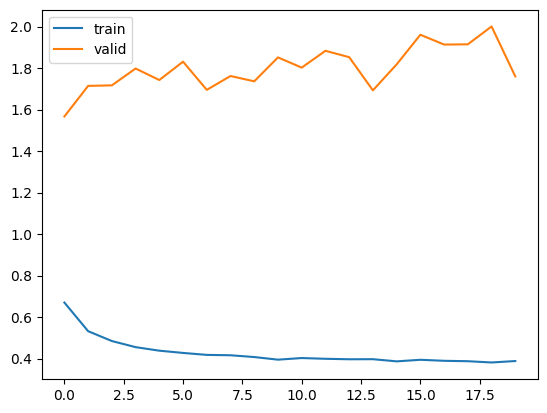

In [78]:
plt.plot(train_losses, label="train")
plt.plot(valid_losses, label="valid")
plt.legend()